# 04 — Training

Trains the AASIST model on the ASVspoof 2019 LA train split and evaluates on the dev split after every epoch.

**Run order:** 01 → 02 → 03 → **04** → 05 → 06  
**Expected time:** ~15–20 min per epoch on an RTX 3060 Ti  
**Checkpoint:** best dev-EER model saved to `checkpoints/best_model.pth`

## Config

In [1]:
config = {
    "data_root"       : "../data",
    "checkpoint_dir"  : "../checkpoints",
    "results_dir"     : "../results/la",
    "num_epochs"      : 100,
    "batch_size"      : 24,
    "lr"              : 1e-4,
    "lr_min"          : 5e-6,
    "weight_decay"    : 1e-4,
    "seed"            : 1234,
    "T_max"           : 100,
    "num_workers"     : 0,
    "pos_weight"      : 9.0,   # spoof:bonafide ≈ 9:1 in train set
    "device"          : "cuda" if __import__('torch').cuda.is_available() else "cpu",
}

print(f"Device : {config['device']}")
print(f"Epochs : {config['num_epochs']}  |  Batch : {config['batch_size']}  |  LR : {config['lr']}")

Device : cuda
Epochs : 100  |  Batch : 24  |  LR : 0.0001


## Setup

In [2]:
import os
import sys
import random
import math
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
from tqdm import tqdm

torchaudio.set_audio_backend("soundfile")

# ── Reproducibility seed ─────────────────────────────────────────────────────
seed = config["seed"]
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

os.makedirs(config["checkpoint_dir"], exist_ok=True)
os.makedirs(config["results_dir"],    exist_ok=True)

device = torch.device(config["device"])
print(f"Seed set to {seed}.  Device: {device}")

Seed set to 1234.  Device: cuda


C:\Users\Pc\AppData\Local\Temp\ipykernel_11920\1356333181.py:17: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")


In [3]:
# ── Inline definitions from 01_dataset and 02_models ─────────────────────────
# (Copy here to make the notebook self-contained; keep in sync with the source.)

ROOT = Path("../")
TARGET_SAMPLES = 64600

PATHS = {
    "train": {
        "audio"   : "data/LA/ASVspoof2019_LA_train/flac",
        "protocol": "data/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt",
    },
    "dev": {
        "audio"   : "data/LA/ASVspoof2019_LA_dev/flac",
        "protocol": "data/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt",
    },
}


def parse_la_protocol(protocol_path):
    label_map = {}
    with open(protocol_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            utt_id    = parts[1]
            attack_id = parts[3]
            key       = parts[4]
            label_map[utt_id] = (0 if key == "bonafide" else 1, attack_id)
    return label_map


class ASVspoofDataset(Dataset):
    def __init__(self, subset, root=ROOT):
        self.audio_dir    = Path(root) / PATHS[subset]["audio"]
        protocol_path     = Path(root) / PATHS[subset]["protocol"]
        label_map         = parse_la_protocol(protocol_path)
        self.items = [(str(self.audio_dir / f"{uid}.flac"), lbl, uid, atk)
                      for uid, (lbl, atk) in label_map.items()]

    def __len__(self):  return len(self.items)

    def __getitem__(self, idx):
        path, label, uid, atk = self.items[idx]
        wav, _ = torchaudio.load(path)
        if wav.size(0) > 1:
            wav = wav.mean(0, keepdim=True)
        n = wav.size(1)
        if n < TARGET_SAMPLES:
            wav = wav.repeat(1, TARGET_SAMPLES // n + 1)
        return wav[:, :TARGET_SAMPLES], label, uid, atk


print("Dataset classes ready.")

Dataset classes ready.


In [4]:
# ── Model definition (inline from 02_models) ─────────────────────────────────

class SincConv1d(nn.Module):
    MIN_LOW_HZ = 50.0;  MIN_BAND_HZ = 50.0
    @staticmethod
    def _to_mel(hz):  return 2595.0 * math.log10(1.0 + hz / 700.0)
    @staticmethod
    def _to_hz(mel):  return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

    def __init__(self, n_filters=70, kernel_size=1024, stride=16, padding=512, sample_rate=16000):
        super().__init__()
        if kernel_size % 2 == 0: kernel_size += 1
        self.stride = stride; self.padding = padding; self.sample_rate = sample_rate
        mel_min = self._to_mel(self.MIN_LOW_HZ)
        mel_max = self._to_mel(sample_rate / 2.0 - self.MIN_BAND_HZ)
        mel_pts = np.linspace(mel_min, mel_max, n_filters + 1)
        hz_pts  = np.array([self._to_hz(m) for m in mel_pts])
        self.low_freq  = nn.Parameter(torch.from_numpy(hz_pts[:-1]).float().unsqueeze(1))
        self.band_freq = nn.Parameter(torch.from_numpy(hz_pts[1:] - hz_pts[:-1]).float().unsqueeze(1))
        half = (kernel_size - 1) // 2
        n = torch.arange(-half, half + 1).float()
        self.register_buffer("window", 0.54 - 0.46 * torch.cos(2.0 * math.pi * (n + half) / (kernel_size - 1)))
        self.register_buffer("n", n)

    def _build_filters(self):
        sr   = float(self.sample_rate)
        low  = self.MIN_LOW_HZ  / sr + torch.abs(self.low_freq)  / sr
        high = low + self.MIN_BAND_HZ / sr + torch.abs(self.band_freq) / sr
        high = torch.clamp(high, max=0.5)
        n    = self.n.unsqueeze(0)
        return ((2.0 * high * torch.sinc(2.0 * high * n) -
                 2.0 * low  * torch.sinc(2.0 * low  * n)) * self.window).unsqueeze(1)

    def forward(self, x):
        return F.conv1d(x, self._build_filters(), stride=self.stride, padding=self.padding)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, first=False):
        super().__init__()
        self.first = first
        if not first: self.bn1 = nn.BatchNorm1d(in_ch)
        self.lrelu = nn.LeakyReLU(0.3, inplace=True)
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1, bias=False)
        self.skip  = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.fms_fc = nn.Linear(out_ch, out_ch)
        self.pool   = nn.MaxPool1d(3)

    def forward(self, x):
        out = x if self.first else self.lrelu(self.bn1(x))
        out = self.lrelu(self.bn2(self.conv1(out)))
        out = self.conv2(out) + self.skip(x)
        scale = torch.sigmoid(self.fms_fc(out.mean(2))).unsqueeze(2)
        return self.pool(out * scale)


class RawNet2Encoder(nn.Module):
    GRU_HIDDEN = 1024
    def __init__(self):
        super().__init__()
        self.sinc = SincConv1d()
        self.bn0  = nn.BatchNorm1d(70)
        self.res1 = ResBlock(70,  20, first=True)
        self.res2 = ResBlock(20,  20)
        self.res3 = ResBlock(20,  128)
        self.res4 = ResBlock(128, 128)
        self.res5 = ResBlock(128, 128)
        self.res6 = ResBlock(128, 128)
        self.bn_pre_gru = nn.BatchNorm1d(128)
        self.gru = nn.GRU(128, self.GRU_HIDDEN, batch_first=True)

    def forward(self, x):
        x = self.bn0(torch.abs(self.sinc(x)))
        x = self.res6(self.res5(self.res4(self.res3(self.res2(self.res1(x))))))
        x = self.bn_pre_gru(x).permute(0, 2, 1)
        self.gru.flatten_parameters()
        x, _ = self.gru(x)                            # [B, T', 1024]
        B, T, H = x.shape
        return x.view(B, T, 128, H // 128).permute(0, 2, 3, 1)  # [B, 128, 8, T']


class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, temperature=1.0, dropout=0.2):
        super().__init__()
        self.temperature = temperature
        self.att_proj       = nn.Linear(in_dim, out_dim)
        self.att_weight     = nn.Parameter(torch.empty(out_dim, 1))
        nn.init.xavier_normal_(self.att_weight)
        self.proj_with_att    = nn.Linear(in_dim, out_dim)
        self.proj_without_att = nn.Linear(in_dim, out_dim)
        self.bn  = nn.BatchNorm1d(out_dim)
        self.drop = nn.Dropout(dropout)
        self.act  = nn.SELU(inplace=True)

    def _att_map(self, x):
        N = x.size(1)
        xi = x.unsqueeze(2).expand(-1,-1,N,-1)
        e  = torch.tanh(self.att_proj(xi * xi.transpose(1,2)))
        return F.softmax(torch.matmul(e, self.att_weight) / self.temperature, dim=2)

    def _bn(self, x):
        s = x.shape; return self.bn(x.view(-1,s[-1])).view(s)

    def forward(self, x):
        x   = self.drop(x)
        att = self._att_map(x)
        out = self.proj_with_att(torch.matmul(att.squeeze(-1), x)) + self.proj_without_att(x)
        return self.act(self._bn(out))


class GraphPool(nn.Module):
    def __init__(self, ratio, in_dim, dropout=0.3):
        super().__init__()
        self.ratio = ratio
        self.proj  = nn.Linear(in_dim, 1)
        self.drop  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.sig   = nn.Sigmoid()

    def forward(self, h):
        scores = self.sig(self.proj(self.drop(h)))
        n_keep = max(int(h.size(1) * self.ratio), 1)
        _, idx = torch.topk(scores, n_keep, dim=1)
        return torch.gather(h * scores, 1, idx.expand(-1,-1,h.size(2)))


class HeterogeneousGraphLayer(nn.Module):
    def __init__(self, in_dim, out_dim, temperature=2.0, dropout=0.2):
        super().__init__()
        self.temperature = temperature
        self.proj_s = nn.Linear(in_dim, in_dim)
        self.proj_t = nn.Linear(in_dim, in_dim)
        self.att_proj = nn.Linear(in_dim, out_dim)
        self.att_w_ss = nn.Parameter(torch.empty(out_dim, 1)); nn.init.xavier_normal_(self.att_w_ss)
        self.att_w_tt = nn.Parameter(torch.empty(out_dim, 1)); nn.init.xavier_normal_(self.att_w_tt)
        self.att_w_st = nn.Parameter(torch.empty(out_dim, 1)); nn.init.xavier_normal_(self.att_w_st)
        self.att_proj_m = nn.Linear(in_dim, out_dim)
        self.att_w_m    = nn.Parameter(torch.empty(out_dim, 1)); nn.init.xavier_normal_(self.att_w_m)
        self.proj_with_att      = nn.Linear(in_dim, out_dim)
        self.proj_without_att   = nn.Linear(in_dim, out_dim)
        self.proj_m_with_att    = nn.Linear(in_dim, out_dim)
        self.proj_m_without_att = nn.Linear(in_dim, out_dim)
        self.bn   = nn.BatchNorm1d(out_dim)
        self.drop = nn.Dropout(dropout)
        self.act  = nn.SELU(inplace=True)

    def _pairwise(self, x):
        N = x.size(1)
        xi = x.unsqueeze(2).expand(-1,-1,N,-1)
        return xi * xi.transpose(1,2)

    def _build_att(self, x, Ns, Nt):
        e = torch.tanh(self.att_proj(self._pairwise(x)))
        board = torch.zeros(*e.shape[:3], 1, device=x.device)
        board[:,:Ns,:Ns,:] = torch.matmul(e[:,:Ns,:Ns,:], self.att_w_ss)
        board[:,Ns:,Ns:,:] = torch.matmul(e[:,Ns:,Ns:,:], self.att_w_tt)
        board[:,:Ns,Ns:,:] = torch.matmul(e[:,:Ns,Ns:,:], self.att_w_st)
        board[:,Ns:,:Ns,:] = torch.matmul(e[:,Ns:,:Ns,:], self.att_w_st)
        return F.softmax(board / self.temperature, dim=2)

    def _update_master(self, x, master):
        att = F.softmax(torch.matmul(torch.tanh(self.att_proj_m(x * master)), self.att_w_m) / self.temperature, dim=1)
        return self.proj_m_with_att(torch.matmul(att.transpose(1,2), x)) + self.proj_m_without_att(master)

    def _bn(self, x):
        s = x.shape; return self.bn(x.view(-1,s[-1])).view(s)

    def forward(self, x_s, x_t, master=None):
        Ns, Nt = x_s.size(1), x_t.size(1)
        x = torch.cat([self.proj_s(x_s), self.proj_t(x_t)], dim=1)
        if master is None: master = x.mean(1, keepdim=True)
        x   = self.drop(x)
        att = self._build_att(x, Ns, Nt)
        m   = self._update_master(x, master)
        out = self.proj_with_att(torch.matmul(att.squeeze(-1), x)) + self.proj_without_att(x)
        out = self.act(self._bn(out))
        return out[:,:Ns,:], out[:,Ns:,:], m


class GraphModule(nn.Module):
    def __init__(self, in_dim=128, gat_dim0=24, gat_dim1=32,
                 pool_ratio_s=0.4, pool_ratio_t=0.5, pool_ratio_hs=0.7, pool_ratio_ht=0.5,
                 temp0=2.0, temp1=100.0):
        super().__init__()
        self.gat_s  = GraphAttentionLayer(in_dim, gat_dim0, temperature=temp0)
        self.gat_t  = GraphAttentionLayer(in_dim, gat_dim0, temperature=temp0)
        self.pool_s = GraphPool(pool_ratio_s, gat_dim0)
        self.pool_t = GraphPool(pool_ratio_t, gat_dim0)
        self.hg1a   = HeterogeneousGraphLayer(gat_dim0, gat_dim1, temperature=temp1)
        self.hg1b   = HeterogeneousGraphLayer(gat_dim1, gat_dim1, temperature=temp1)
        self.pool_hs1 = GraphPool(pool_ratio_hs, gat_dim1)
        self.pool_ht1 = GraphPool(pool_ratio_hs, gat_dim1)
        self.hg2a   = HeterogeneousGraphLayer(gat_dim0, gat_dim1, temperature=temp1)
        self.hg2b   = HeterogeneousGraphLayer(gat_dim1, gat_dim1, temperature=temp1)
        self.pool_hs2 = GraphPool(pool_ratio_hs, gat_dim1)
        self.pool_ht2 = GraphPool(pool_ratio_hs, gat_dim1)
        self.drop_way = nn.Dropout(0.2)
        self.readout_dim = 5 * gat_dim1
        self.master1 = nn.Parameter(torch.randn(1, 1, gat_dim0))
        self.master2 = nn.Parameter(torch.randn(1, 1, gat_dim0))

    def forward(self, feat):
        e_s, _ = feat.abs().max(3);  e_s = e_s.permute(0,2,1)
        e_t, _ = feat.abs().max(2);  e_t = e_t.permute(0,2,1)
        s  = self.pool_s(self.gat_s(e_s))
        t  = self.pool_t(self.gat_t(e_t))
        B  = feat.size(0)
        m1 = self.master1.expand(B,-1,-1);  m2 = self.master2.expand(B,-1,-1)
        s1, t1, m1 = self.hg1a(s, t, master=m1)
        s1 = self.pool_hs1(s1);  t1 = self.pool_ht1(t1)
        s1a, t1a, m1a = self.hg1b(s1, t1, master=m1)
        s1, t1, m1 = s1+s1a, t1+t1a, m1+m1a
        s2, t2, m2 = self.hg2a(s, t, master=m2)
        s2 = self.pool_hs2(s2);  t2 = self.pool_ht2(t2)
        s2a, t2a, m2a = self.hg2b(s2, t2, master=m2)
        s2, t2, m2 = s2+s2a, t2+t2a, m2+m2a
        s_o = self.drop_way(torch.max(s1, s2))
        t_o = self.drop_way(torch.max(t1, t2))
        m_o = self.drop_way(torch.max(m1, m2))
        return torch.cat([t_o.abs().max(1)[0], t_o.mean(1),
                          s_o.abs().max(1)[0], s_o.mean(1),
                          m_o.squeeze(1)], dim=1)


class AASIST(nn.Module):
    GAT_DIMS=[24,32]; POOL_RATIOS=[0.4,0.5,0.7,0.5]; TEMPS=[2.0,2.0,100.0,100.0]
    def __init__(self):
        super().__init__()
        gd,pr,tp = self.GAT_DIMS, self.POOL_RATIOS, self.TEMPS
        self.encoder = RawNet2Encoder()
        self.graph   = GraphModule(in_dim=128, gat_dim0=gd[0], gat_dim1=gd[1],
                                   pool_ratio_s=pr[0], pool_ratio_t=pr[1],
                                   pool_ratio_hs=pr[2], pool_ratio_ht=pr[3],
                                   temp0=tp[0], temp1=tp[2])
        self.drop = nn.Dropout(0.5)
        self.out  = nn.Linear(self.graph.readout_dim, 2)

    def forward(self, x):
        return self.out(self.drop(self.graph(self.encoder(x))))


print("All model classes ready.")

All model classes ready.


In [5]:
# ── Metrics (inline from 03_metrics) ─────────────────────────────────────────
import os as _os
from sklearn.metrics import roc_curve as _roc_curve

def compute_eer(scores, labels, prefix="la", save_dir="../results/la"):
    fpr, tpr, thr = _roc_curve(labels, scores, pos_label=1)
    fnr = 1.0 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = float((fpr[idx] + fnr[idx]) / 2.0)
    return eer, float(thr[idx])

print("compute_eer() ready.")

compute_eer() ready.


## Dataset & DataLoader

In [6]:
def collate_fn(batch):
    wavs, labels, uids, atks = zip(*batch)
    return torch.stack(wavs), torch.tensor(labels), list(uids), list(atks)

train_ds = ASVspoofDataset("train")
dev_ds   = ASVspoofDataset("dev")

train_loader = DataLoader(train_ds, batch_size=config["batch_size"],
                          shuffle=True,  num_workers=config["num_workers"],
                          collate_fn=collate_fn, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=config["batch_size"],
                          shuffle=False, num_workers=config["num_workers"],
                          collate_fn=collate_fn, pin_memory=True)

print(f"Train : {len(train_ds):,} samples  |  Dev : {len(dev_ds):,} samples")
print(f"Train batches : {len(train_loader)}  |  Dev batches : {len(dev_loader)}")

Train : 25,380 samples  |  Dev : 24,844 samples
Train batches : 1058  |  Dev batches : 1036


## Model, Optimizer, Scheduler, Loss

In [7]:
model     = AASIST().to(device)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=config["lr"],
                             weight_decay=config["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=config["T_max"], eta_min=config["lr_min"])

# BCEWithLogitsLoss on logits[:,1] (spoof class score)
# pos_weight upweights the spoof class because bonafide is the majority class
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([config["pos_weight"]], device=device))

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {total_params:,}")
print(f"Optimizer        : Adam  lr={config['lr']}  wd={config['weight_decay']}")
print(f"Scheduler        : CosineAnnealingLR  T_max={config['T_max']}")

Model parameters : 4,026,904
Optimizer        : Adam  lr=0.0001  wd=0.0001
Scheduler        : CosineAnnealingLR  T_max=100


## Training Loop

In [8]:
best_eer      = float("inf")
best_epoch    = 0
loss_history  = []
eer_history   = []

ckpt_path     = os.path.join(config["checkpoint_dir"], "best_model.pth")

for epoch in range(1, config["num_epochs"] + 1):

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch:03d} [train]", position=0, leave=True, unit="batch")
    for wavs, labels, *_ in train_pbar:
        wavs   = wavs.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        logits = model(wavs)                       # [B, 2]
        loss   = criterion(logits[:, 1], labels)   # spoof-class logit vs float label
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        train_pbar.set_postfix({"loss": f"{running_loss / (train_pbar.n or 1):.4f}"})

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)

    # ── Dev evaluation ───────────────────────────────────────────────────────
    model.eval()
    all_scores, all_labels = [], []
    dev_pbar = tqdm(dev_loader, desc=f"Epoch {epoch:03d} [dev]", position=0, leave=False, unit="batch")
    with torch.no_grad():
        for wavs, labels, *_ in dev_pbar:
            logits = model(wavs.to(device))        # [B, 2]
            scores = torch.sigmoid(logits[:, 1])   # spoof probability
            all_scores.append(scores.cpu().numpy())
            all_labels.append(labels.numpy())

    all_scores = np.concatenate(all_scores)
    all_labels = np.concatenate(all_labels)
    dev_eer, _ = compute_eer(all_scores, all_labels)
    eer_history.append(dev_eer)

    if dev_eer < best_eer:
        best_eer   = dev_eer
        best_epoch = epoch
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "dev_eer"    : dev_eer,
        }, ckpt_path)

    scheduler.step()

    marker = " <-- best" if epoch == best_epoch else ""
    print(f"Epoch {epoch:03d}/{config['num_epochs']} | "
          f"Loss: {avg_loss:.4f} | Dev EER: {dev_eer*100:.2f}%{marker}")

print(f"\nTraining complete.  Best Dev EER: {best_eer*100:.2f}% at epoch {best_epoch}")
print(f"Checkpoint saved to: {ckpt_path}")

Epoch 001 [train]: 100%|██████████| 1058/1058 [01:47<00:00,  9.86batch/s, loss=0.9460]


Epoch 001/100 | Loss: 0.9451 | Dev EER: 27.32% <-- best


Epoch 002 [train]: 100%|██████████| 1058/1058 [04:27<00:00,  3.95batch/s, loss=0.4641]


Epoch 002/100 | Loss: 0.4637 | Dev EER: 16.93% <-- best


Epoch 003 [train]: 100%|██████████| 1058/1058 [04:08<00:00,  4.27batch/s, loss=0.3044]


...

Epoch 098/100 | Loss: 0.0001 | Dev EER: 0.81%


Epoch 099 [train]: 100%|██████████| 1058/1058 [01:47<00:00,  9.83batch/s, loss=0.0002]


Epoch 099/100 | Loss: 0.0002 | Dev EER: 0.59% <-- best


Epoch 100 [train]: 100%|██████████| 1058/1058 [01:47<00:00,  9.85batch/s, loss=0.0001]
                                                                       

Epoch 100/100 | Loss: 0.0001 | Dev EER: 0.66%

Training complete.  Best Dev EER: 0.59% at epoch 99
Checkpoint saved to: ../checkpoints\best_model.pth


## Results

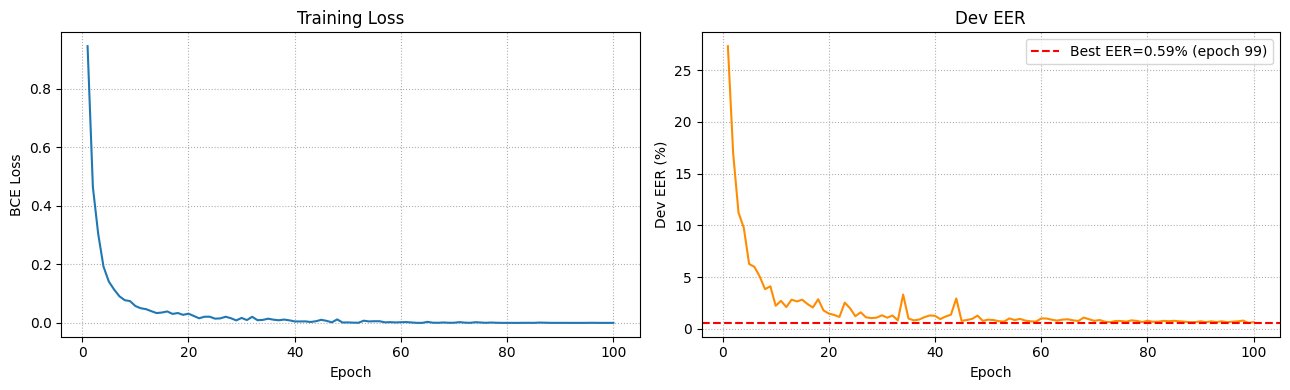

Training curves saved to ../results/la\training_curves.png
Best Dev EER: 0.59% at epoch 99


In [9]:
epochs = range(1, len(loss_history) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, loss_history, linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("Training Loss")
ax1.grid(True, linestyle=":")

ax2.plot(epochs, [e * 100 for e in eer_history], linewidth=1.5, color="darkorange")
ax2.axhline(best_eer * 100, color="red", linestyle="--",
            label=f"Best EER={best_eer*100:.2f}% (epoch {best_epoch})")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dev EER (%)")
ax2.set_title("Dev EER")
ax2.legend()
ax2.grid(True, linestyle=":")

plt.tight_layout()
out_path = os.path.join(config["results_dir"], "training_curves.png")
plt.savefig(out_path, dpi=120)
plt.show()
print(f"Training curves saved to {out_path}")
print(f"Best Dev EER: {best_eer*100:.2f}% at epoch {best_epoch}")